## Weather Prediciton using Neural Network
# Introduction
blah

In [16]:
import numpy as np
import pandas as pd
import torch 
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import openmeteo_requests, requests_cache, retry_requests
import time
from matplotlib import pyplot as plt

device = "cuda" if torch.cuda.is_available() else "mps"
torch.manual_seed(42)

print(f"Using device {device}")

Using device mps


# Importing the dataset

In [17]:
cache = requests_cache.CachedSession(".cache") 
retry_session = retry_requests.retry(cache, retries=5, backoff_factor=5)
openmeteo = openmeteo_requests.Client(session=retry_session)

url = "https://archive-api.open-meteo.com/v1/archive"
params_to_import = {
    "latitude": 51.76,
    "longitude" : 18.08,
    "start_date" : "2000-01-01",
    "end_date": "2026-06-01",
    "hourly" : ["temperature_2m", "rain", "precipitation", "relative_humidity_2m", "dew_point_2m", "wind_speed_10m", "wind_direction_10m", "wind_speed_100m", "wind_direction_100m"]
}
responses = openmeteo.weather_api(url, params=params_to_import) 

response = responses[0]
print(f"Coordinates: {response.Latitude()} {response.Longitude()}")

hourly = response.Hourly()
temperature = hourly.Variables(0).ValuesAsNumpy()
rain = hourly.Variables(1).ValuesAsNumpy()
precipitation = hourly.Variables(2).ValuesAsNumpy()
relative_humidity = hourly.Variables(3).ValuesAsNumpy()
dew_point = hourly.Variables(4).ValuesAsNumpy()
wind_speed_10m = hourly.Variables(5).ValuesAsNumpy()
wind_direction_10m = hourly.Variables(6).ValuesAsNumpy()
wind_speed_100m = hourly.Variables(7).ValuesAsNumpy()
wind_direction_100m = hourly.Variables(8).ValuesAsNumpy()

dates = pd.date_range(
	start = pd.to_datetime(hourly.Time(), unit="s", utc=True),
	end = pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
 	freq = pd.Timedelta(seconds=hourly.Interval()),
	inclusive="left"
)

data = {
	"temperature": temperature,
	"rain" : rain,
	"precipitation" : precipitation,
	"relative_humidity" : relative_humidity,
	"dew_point" : dew_point,
	"wind_speed_10m" :wind_speed_10m,
	"wind_speed_100m" : wind_speed_100m,
	"wind_direction_10m" : wind_direction_10m,
	"wind_direction_100m" : wind_direction_100m
}

data = pd.DataFrame(data, index=dates)
data.describe()


Coordinates: 51.77504348754883 18.065692901611328


,temperature,rain,precipitation,relative_humidity,dew_point,wind_speed_10m,wind_speed_100m,wind_direction_10m,wind_direction_100m
count,231576.000000,231576.000000,231576.000000,231576.000000,231576.000000,231576.000000,231576.000000,231576.000000,231576.000000
mean,9.853207,0.063361,0.069865,74.992805,5.091573,13.551030,22.629902,201.181091,203.285629
std,8.818685,0.285390,0.291513,17.098455,7.237552,6.464439,9.994681,93.112885,94.009117
min,-28.952499,0.000000,0.000000,16.743015,-31.752501,0.000000,0.000000,0.674022,0.387126
25%,3.097500,0.000000,0.000000,63.302700,0.247500,8.707238,15.683776,126.869987,128.118332
50%,9.747499,0.000000,0.000000,78.692127,5.447500,12.661564,22.057161,217.184784,221.633438
75%,16.597500,0.000000,0.000000,89.328320,10.597500,17.283749,28.594517,275.906036,278.746063
max,36.647499,19.500000,19.500000,100.000000,22.847500,66.087212,99.196167,360.000000,360.000000


Now we will build a Dataset class, where we will store our data. This is to simplify later steps using Dataloader and training process.

In [18]:
class WeatherDataset(Dataset):
    def __init__(self, data, window_size=24):
        self.data = data
        self.window_size = window_size
    
    def __len__(self):
        return len(self.data) - self.window_size

    def __getitem__(self, index):
        x = self.data[index : index + self.window_size]
        y = self.data[index + self.window_size]
        return x, y

# Data inspection
Before we start creating the neural netowrk, it is wise to analyze the data we will be working with. This is to familiarize ourselves with is and see if our intuition is correct.

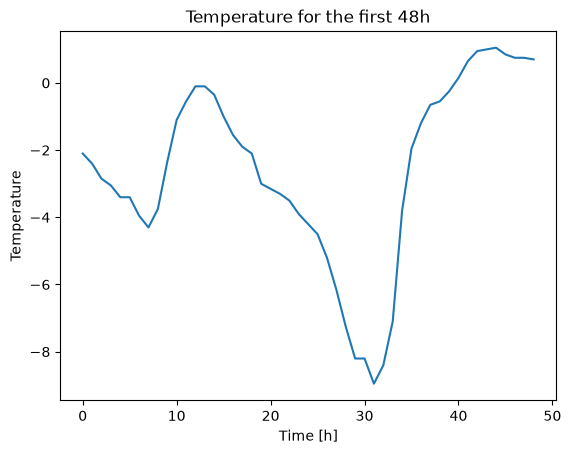

In [19]:
plt.plot(range(49), data["temperature"][:49])
plt.xlabel("Time [h]")
plt.ylabel("Temperature")
plt.title("Temperature for the first 48h")

plt.show()

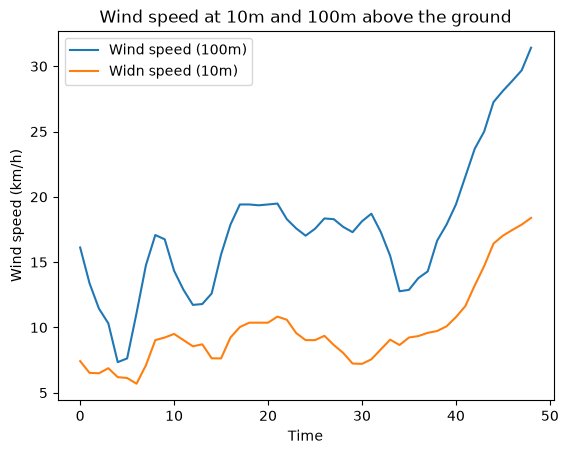

In [20]:
plt.plot(range(49), data["wind_speed_100m"][:49], label="Wind speed (100m)")
plt.plot(range(49), data["wind_speed_10m"][:49], label="Widn speed (10m)")
plt.title("Wind speed at 10m and 100m above the ground")
plt.xlabel("Time")
plt.ylabel("Wind speed (km/h)")
plt.legend()
plt.show()

# Initialization of the Neural Network
For this task I will use convolution to extract the features from data and LSTM to preserve time information. 

First we need to normalize the data, since almost each feature has a different scale. For that I will use `Z-score` normalization.

In [21]:
for feature in data:
    mean = np.mean(data[feature])
    std_dev = np.std(data[feature])
    z_score = (data[feature] - mean) / std_dev
    data[feature] = z_score
   
data.describe()

,temperature,rain,precipitation,relative_humidity,dew_point,wind_speed_10m,wind_speed_100m,wind_direction_10m,wind_direction_100m
count,2.315760e+05,2.315760e+05,2.315760e+05,2.315760e+05,2.315760e+05,2.315760e+05,2.315760e+05,2.315760e+05,2.315760e+05
mean,6.325542e-09,-8.565839e-09,8.829403e-09,-8.434056e-09,-8.434056e-09,9.751878e-09,9.172036e-08,-5.218572e-08,-1.449603e-07
std,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00
min,-4.400406e+00,-2.220179e-01,-2.396647e-01,-3.406735e+00,-5.090693e+00,-2.096247e+00,-2.264199e+00,-2.153381e+00,-2.158290e+00
25%,-7.660691e-01,-2.220179e-01,-2.396647e-01,-6.836951e-01,-6.692986e-01,-7.492996e-01,-6.949838e-01,-7.980771e-01,-7.995763e-01
50%,-1.198675e-02,-2.220179e-01,-2.396647e-01,2.163546e-01,4.917792e-02,-1.375940e-01,-5.730466e-02,1.718745e-01,1.951710e-01
75%,7.647748e-01,-2.220179e-01,-2.396647e-01,8.384116e-01,7.607460e-01,5.774246e-01,5.967802e-01,8.025216e-01,8.026945e-01
max,3.038361e+00,6.810575e+01,6.665292e+01,1.462544e+00,2.453311e+00,8.126968e+00,7.660718e+00,1.705663e+00,1.667016e+00


Now we will split the data into train and test subsets. The first 80% of the original dataset will be assigned to train and the rest 20% to test.
We also need to comvert the data to tensors, so that it is possible to move it to the current `device`.

In [22]:
data_train = data[:int(len(data) * 0.8)].to_numpy()
data_test = data[int(len(data) * 0.8):].to_numpy()

data_train = torch.tensor(data_train, dtype=torch.float32)
data_test = torch.tensor(data_test, dtype=torch.float32)

train_dataset = WeatherDataset(data_train)
test_dataset = WeatherDataset(data_test)

We can see that the data was correctly normalized using `Z-scores`. However, looking at `rain` and `percipitation`. The `min`, `25%` and `75%` values are the same, showing that the data is highly skewed. For now we will ignore this, but if needed we will come back to this in the later part. 

In [23]:
class ConvLSTM(nn.Module):
    def __init__(self):
        """
        Initializtion of all the layers or the neural network.
        The first convolutional layer, consists in real of two convolution layers, after each one ReLU is applied.
        """
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_channels=9, out_channels=32, kernel_size=4, padding=1),
            nn.ReLU(),
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU()
        )
        self.lstm = nn.LSTM(
            input_size=64, hidden_size=64, num_layers=2, batch_first=True
        )
        self.linear = nn.Linear(64, 9)
    
    def forward(self, x):
        """The method that calls all the layers one by one. Returns the output of the network.

        Args:
            x (_type_): The input data that goes through the network.
        """
        x = x.permute(0, 2, 1)
        out = self.conv(x)
        
        out = out.permute(0, 2, 1)
        out, (h_n, c_n) = self.lstm(out)
        
        out = self.linear(out[:, -1, :])
        
        return out

Now we will train the network and store the accuracies

In [25]:
def train(network, train, test, epochs, optimizer, loss_fn):
    """This function is called to train the network on the data.

    Args:
        network (_type_): network that needs to be trained
        train (_type_): the train dataset
        test (_type_): the test dataset
    """
    
    model = network.to(device)
    loss_fn = loss_fn()
    
    optimizer = optimizer(model.parameters())
    
    train_dataloader = DataLoader(train, batch_size=64)
    
    for _ in range(epochs):
        model.train()
        
        for x_train, y_train in train_dataloader:
            x_train = x_train.to(device)
            y_train = y_train.to(device)
            
            pred = model(x_train)
            loss = loss_fn(pred, y_train)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
    torch.save(model.state_dict(), 'model.pth')
        
    
train(ConvLSTM(), train_dataset, test_dataset, 15, torch.optim.Adam, nn.MSELoss)
    

In [ ]:
def check_accuracy(model, weights, test):
    model.load_state_dict(torch.load(weights))
    
    test_dataloader = DataLoader(test_dataset, batch_size=1)
    
    for x_test, y_test in test_dataloader:
        x_test = x_test.to(device)
        y_test = y_test.to(device)
        
        
        
check_accuracy(ConvLSTM(), "model.pth", test_dataset)

RuntimeError: Input type (MPSFloatType) and weight type (torch.FloatTensor) should be the same